<img src="./logo_UNSAM.jpg" align="right" width="250" />  -->
# Análisis y Procesamiento de Señales

## Trabajo Práctico Nº3
#### Sofía Gervasi


# Introducción

En esta actividad se continuará con la modelización de un conversor analógico-digital (ADC), incorporando ahora la etapa de muestreo a una frecuencia determinada. A partir del bloque de cuantización desarrollado en clase, se simulará el comportamiento completo del ADC al digitalizar una señal senoidal contaminada con ruido gaussiano aditivo. El objetivo es analizar cómo influyen distintos niveles de resolución y ruido sobre el resultado final de la conversión, evaluando el desempeño del sistema en función de sus parámetros clave.


## I. Simulación del bloque de cuantización de un ADC de 4 bits y kn=1

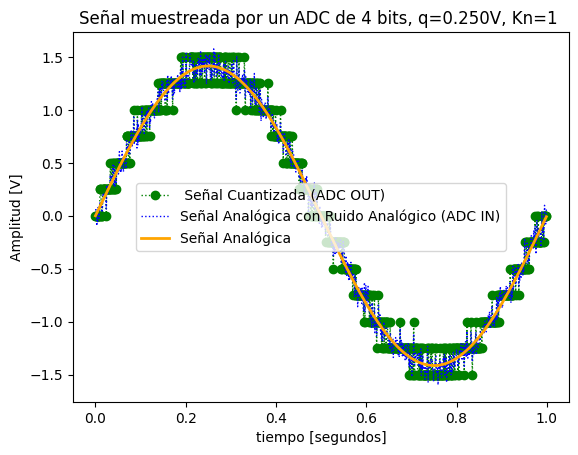

Text(0.5, 0, 'Pasos de cuantización (q) [V]')

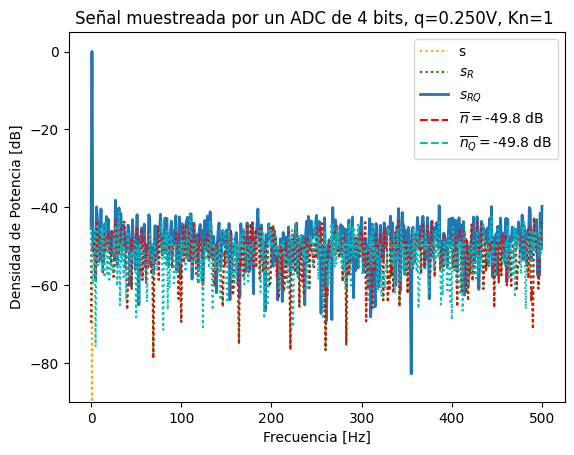

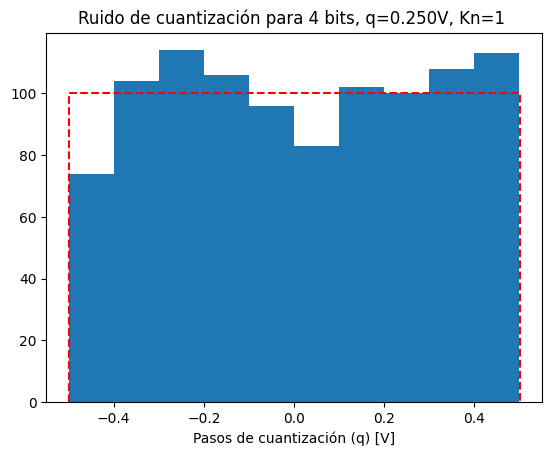

In [6]:
# -*- coding: utf-8 -*-
"""
Created on Sun Mar 30 15:35:49 2025

@author: Sofía
"""

# módulos y funciones a importar
import matplotlib.pyplot as plt
import numpy as np

## Parte A

# Datos de la simulación

fs = 1000 # frecuencia de muestreo (Hz)
N = 1000 # cantidad de muestras
f0 = 1 # Hz
ts = 1/fs  # tiempo de muestreo
df =fs/N  # resolución espectral

#%% Datos del ADC
B = 4 # bits
Vf = 2 # rango simétrico de +/- Vf Volts
q =  Vf/2**(B-1) #paso de cuantización de q Volts

# Datos del ruido 
Pnq = q**2/12# Potencia ruido cuántico [Watts]
kn = 1 # escala de la potencia de ruido analógico
Pna = Pnq * kn # Potencia ruido analógico [Watts] 


#%% Grilla de sampleo temporal

tt = np.linspace(0, (N-1)*ts, N) #tiempo de la experiencia

arg = 2*np.pi*f0*tt

xx = np.sqrt(2)*np.sin(arg) #Señal de energía normalizada
varianza = np.var(xx) #escalar por el desvio estandar

s = xx/np.sqrt(varianza) # señal analógica normalizada sin ruido
nn = np.random.normal(0, np.sqrt(Pna), N) # señal de ruido de analógico
sr = s + nn  # señal analógica de entrada al ADC (con ruido analógico)
srq = np.round(sr/q)*q # señal cuantizada

nq = srq - sr # señal de ruido de cuantización

#%%Señal temporal

plt.figure(1)

plt.plot(tt, srq, lw=1, color='green', marker='o', ls='dotted', label=' Señal Cuantizada (ADC OUT)')
plt.plot(tt, sr, lw=1, color='blue', marker='', ls='dotted', label='Señal Analógica con Ruido Analógico (ADC IN)')
plt.plot(tt, s, lw=2, color='orange', marker='', ls='solid', label='Señal Analógica')

plt.title('Señal muestreada por un ADC de {:d} bits, q={:3.3f}V, Kn={:d} '.format(B, q, kn))
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')
axes_hdl = plt.gca()
axes_hdl.legend()
plt.show()

#%%Espectro

plt.figure(2)
ft_SR = 1/N*np.fft.fft( sr) #Vector de N muestras, num. complejos
ft_Srq = 1/N*np.fft.fft( srq)
ft_As = 1/N*np.fft.fft( s)
ft_Nq = 1/N*np.fft.fft( nq)
ft_Nn = 1/N*np.fft.fft( nn)

# Grilla de sampleo frecuencial
ff = np.linspace(0, (N-1)*df, N)

bfrec = ff <= fs/2

Nnq_mean = np.mean(np.abs(ft_Nq)**2)
nNn_mean = np.mean(np.abs(ft_Nn)**2)


plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_As[bfrec])**2), color='orange', ls='dotted', label='s' )
plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_SR[bfrec])**2), ':g', label='$ s_R $' )
plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_Srq[bfrec])**2), lw=2, label='$ s_{RQ}$' )
plt.plot( np.array([ ff[bfrec][0], ff[bfrec][-1] ]), 10* np.log10(2* np.array([nNn_mean, nNn_mean]) ), '--r', label= '$ \overline{n} = $' + '{:3.1f} dB'.format(10* np.log10(2* nNn_mean)) )
plt.plot( np.array([ ff[bfrec][0], ff[bfrec][-1] ]), 10* np.log10(2* np.array([Nnq_mean, Nnq_mean]) ), '--c', label='$ \overline{n_Q} = $' + '{:3.1f} dB'.format(10* np.log10(2* Nnq_mean)) )
plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_Nn[bfrec])**2), ':r')
plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_Nq[bfrec])**2), ':c')



plt.title('Señal muestreada por un ADC de {:d} bits, q={:3.3f}V, Kn={:d} '.format(B, q, kn))
plt.ylabel('Densidad de Potencia [dB]')
plt.xlabel('Frecuencia [Hz]')
plt.ylim([-90, 5])
axes_hdl = plt.gca()
axes_hdl.legend()

#%% Histograma


plt.figure(3)
bins = 10
plt.hist(nq.flatten()/(q), bins=bins)
plt.plot( np.array([-1/2, -1/2, 1/2, 1/2]), np.array([0, N/bins, N/bins, 0]), '--r')
plt.title( 'Ruido de cuantización para {:d} bits, q={:3.3f}V, Kn={:d} '.format(B, q, kn))
plt.xlabel('Pasos de cuantización (q) [V]')


## II. Simulación del bloque de cuantización de un ADC de 4 bits y kn=0.1

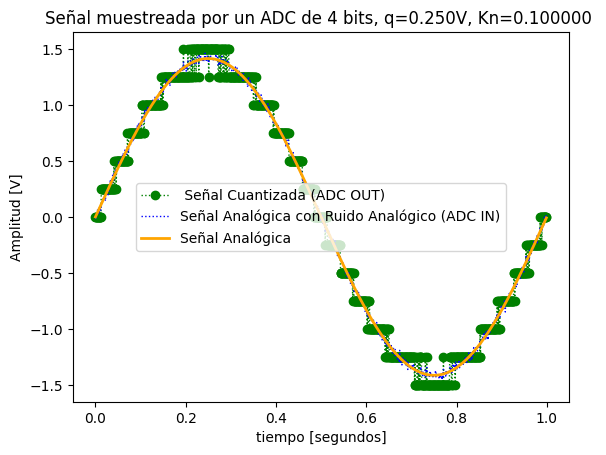

Text(0.5, 0, 'Pasos de cuantización (q) [V]')

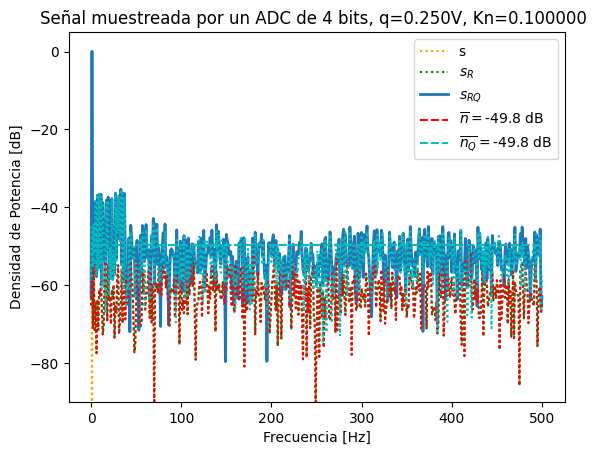

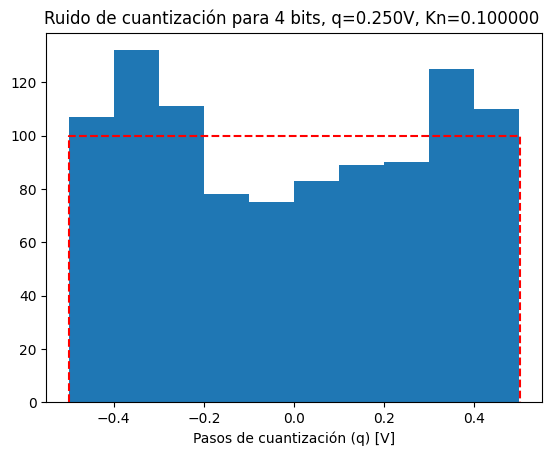

In [7]:
#%% Datos del ADC
B = 4 # bits
q =  Vf/2**(B-1)# paso de cuantización de q Volts

#%% Datos del Ruido 
kn = 1/10 # escala de la potencia de ruido analógico
Pna = Pnq * kn # Potencia ruido analógico [Watts] 

#%% Grilla de sampleo temporal
nn = np.random.normal(0, np.sqrt(Pna), N) # señal de ruido de analógico
sr = s + nn# señal analógica de entrada al ADC (con ruido analógico)
srq = np.round(sr/q)*q # señal cuantizada
nq = srq - sr # señal de ruido de cuantización


plt.figure(1)

plt.plot(tt, srq, lw=1, color='green', marker='o', ls='dotted', label=' Señal Cuantizada (ADC OUT)')
plt.plot(tt, sr, lw=1, color='blue', marker='', ls='dotted', label='Señal Analógica con Ruido Analógico (ADC IN)')
plt.plot(tt, s, lw=2, color='orange', marker='', ls='solid', label='Señal Analógica')

plt.title('Señal muestreada por un ADC de {:d} bits, q={:3.3f}V, Kn={:f} '.format(B, q, kn))
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')
axes_hdl = plt.gca()
axes_hdl.legend()
plt.show()


#%% Espectro

plt.figure(2)
ft_SR = 1/N*np.fft.fft( sr) #Vector de N muestras, num. complejos
ft_Srq = 1/N*np.fft.fft( srq)
ft_As = 1/N*np.fft.fft( s)
ft_Nq = 1/N*np.fft.fft( nq)
ft_Nn = 1/N*np.fft.fft( nn)


plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_As[bfrec])**2), color='orange', ls='dotted', label='s' )
plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_SR[bfrec])**2), ':g', label='$ s_R $' )
plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_Srq[bfrec])**2), lw=2, label='$ s_{RQ}$' )
plt.plot( np.array([ ff[bfrec][0], ff[bfrec][-1] ]), 10* np.log10(2* np.array([nNn_mean, nNn_mean]) ), '--r', label= '$ \overline{n} = $' + '{:3.1f} dB'.format(10* np.log10(2* nNn_mean)) )
plt.plot( np.array([ ff[bfrec][0], ff[bfrec][-1] ]), 10* np.log10(2* np.array([Nnq_mean, Nnq_mean]) ), '--c', label='$ \overline{n_Q} = $' + '{:3.1f} dB'.format(10* np.log10(2* Nnq_mean)) )
plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_Nn[bfrec])**2), ':r')
plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_Nq[bfrec])**2), ':c')



plt.title('Señal muestreada por un ADC de {:d} bits, q={:3.3f}V, Kn={:f} '.format(B, q, kn))
plt.ylabel('Densidad de Potencia [dB]')
plt.xlabel('Frecuencia [Hz]')
plt.ylim([-90, 5])
axes_hdl = plt.gca()
axes_hdl.legend()


#%% Histograma


plt.figure(3)
bins = 10
plt.hist(nq.flatten()/(q), bins=bins)
plt.plot( np.array([-1/2, -1/2, 1/2, 1/2]), np.array([0, N/bins, N/bins, 0]), '--r' )
plt.title( 'Ruido de cuantización para {:d} bits, q={:3.3f}V, Kn={:f} '.format(B, q, kn))

plt.xlabel('Pasos de cuantización (q) [V]')




## III. Simulación del bloque de cuantización de un ADC de 16 bits y kn=1

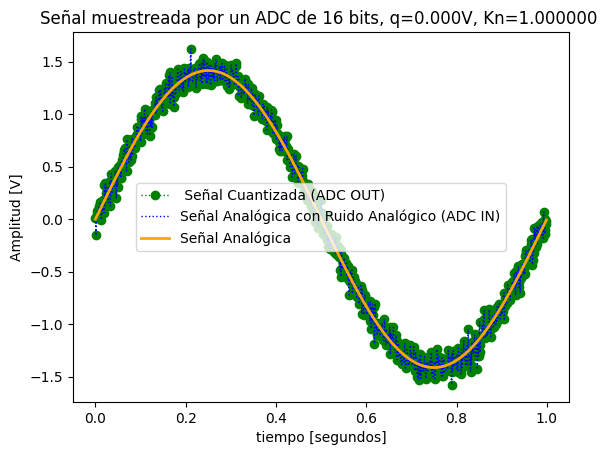

Text(0.5, 0, 'Pasos de cuantización (q) [V]')

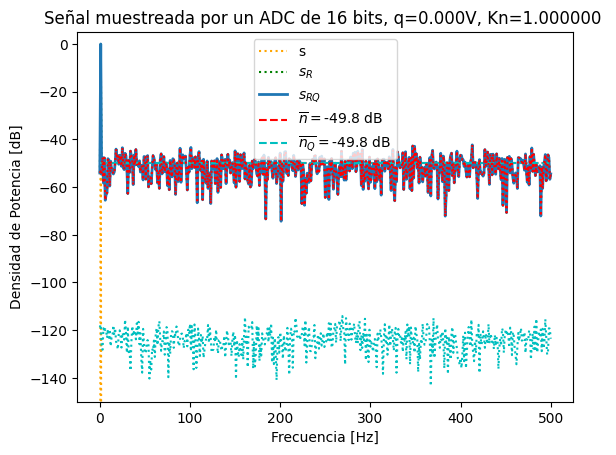

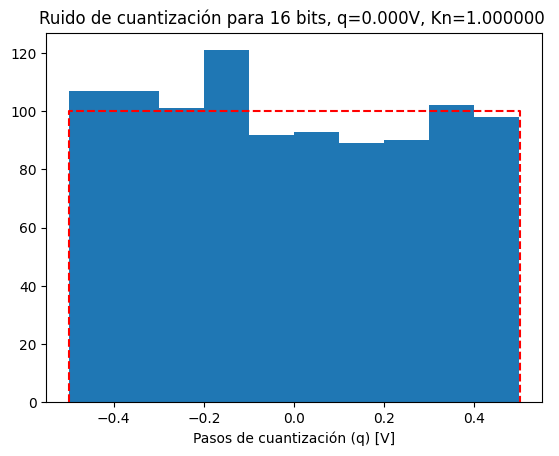

In [10]:
#%% Datos del ADC
B = 16 # bits
q =  Vf/2**(B-1)# paso de cuantización de q Volts

#%% Datos del Ruido 
kn = 1 # escala de la potencia de ruido analógico
Pna = Pnq * kn # Potencia ruido analógico [Watts] 

#%% Grilla de sampleo temporal
nn = np.random.normal(0, np.sqrt(Pna), N) # señal de ruido de analógico
sr = s + nn# señal analógica de entrada al ADC (con ruido analógico)
srq = np.round(sr/q)*q # señal cuantizada
nq = srq - sr # señal de ruido de cuantización


plt.figure(1)

plt.plot(tt, srq, lw=1, color='green', marker='o', ls='dotted', label=' Señal Cuantizada (ADC OUT)')
plt.plot(tt, sr, lw=1, color='blue', marker='', ls='dotted', label='Señal Analógica con Ruido Analógico (ADC IN)')
plt.plot(tt, s, lw=2, color='orange', marker='', ls='solid', label='Señal Analógica')

plt.title('Señal muestreada por un ADC de {:d} bits, q={:3.3f}V, Kn={:f} '.format(B, q, kn))
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')
axes_hdl = plt.gca()
axes_hdl.legend()
plt.show()


#%% Espectro

plt.figure(2)
ft_SR = 1/N*np.fft.fft( sr) #Vector de N muestras, num. complejos
ft_Srq = 1/N*np.fft.fft( srq)
ft_As = 1/N*np.fft.fft( s)
ft_Nq = 1/N*np.fft.fft( nq)
ft_Nn = 1/N*np.fft.fft( nn)


plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_As[bfrec])**2), color='orange', ls='dotted', label='s' )
plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_SR[bfrec])**2), ':g', label='$ s_R $' )
plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_Srq[bfrec])**2), lw=2, label='$ s_{RQ}$' )
plt.plot( np.array([ ff[bfrec][0], ff[bfrec][-1] ]), 10* np.log10(2* np.array([nNn_mean, nNn_mean]) ), '--r', label= '$ \overline{n} = $' + '{:3.1f} dB'.format(10* np.log10(2* nNn_mean)) )
plt.plot( np.array([ ff[bfrec][0], ff[bfrec][-1] ]), 10* np.log10(2* np.array([Nnq_mean, Nnq_mean]) ), '--c', label='$ \overline{n_Q} = $' + '{:3.1f} dB'.format(10* np.log10(2* Nnq_mean)) )
plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_Nn[bfrec])**2), ':r')
plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_Nq[bfrec])**2), ':c')



plt.title('Señal muestreada por un ADC de {:d} bits, q={:3.3f}V, Kn={:f} '.format(B, q, kn))
plt.ylabel('Densidad de Potencia [dB]')
plt.xlabel('Frecuencia [Hz]')
plt.ylim([-150, 5])
axes_hdl = plt.gca()
axes_hdl.legend()


#%% Histograma


plt.figure(3)
bins = 10
plt.hist(nq.flatten()/(q), bins=bins)
plt.plot( np.array([-1/2, -1/2, 1/2, 1/2]), np.array([0, N/bins, N/bins, 0]), '--r' )
plt.title( 'Ruido de cuantización para {:d} bits, q={:3.3f}V, Kn={:f} '.format(B, q, kn))
plt.xlabel('Pasos de cuantización (q) [V]')

## III. Simulación del bloque de cuantización de un ADC de 8 bits y kn=10

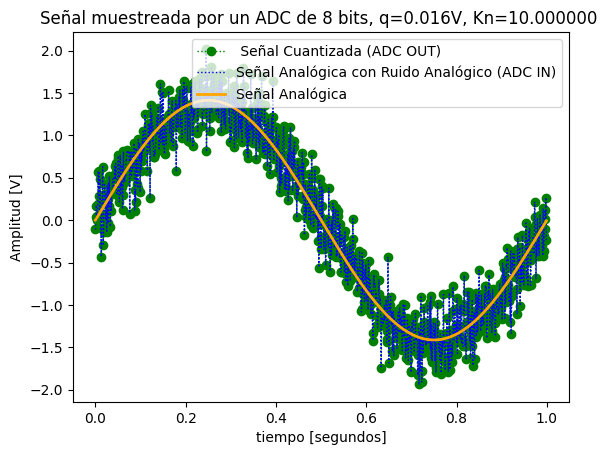

Text(0.5, 0, 'Pasos de cuantización (q) [V]')

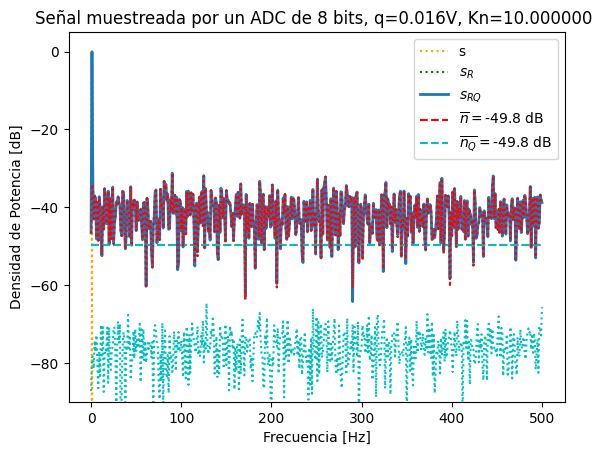

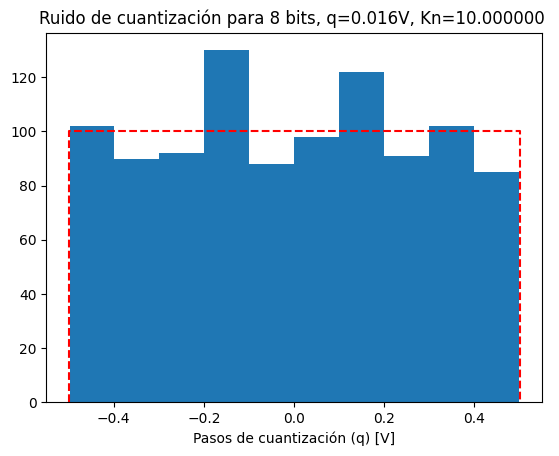

In [9]:
#%% Datos del ADC
B = 8 # bits
q =  Vf/2**(B-1)# paso de cuantización de q Volts

#%% Datos del Ruido 
kn = 10 # escala de la potencia de ruido analógico
Pna = Pnq * kn # Potencia ruido analógico [Watts] 

#%% Grilla de sampleo temporal
nn = np.random.normal(0, np.sqrt(Pna), N) # señal de ruido de analógico
sr = s + nn# señal analógica de entrada al ADC (con ruido analógico)
srq = np.round(sr/q)*q # señal cuantizada
nq = srq - sr # señal de ruido de cuantización


plt.figure(1)

plt.plot(tt, srq, lw=1, color='green', marker='o', ls='dotted', label=' Señal Cuantizada (ADC OUT)')
plt.plot(tt, sr, lw=1, color='blue', marker='', ls='dotted', label='Señal Analógica con Ruido Analógico (ADC IN)')
plt.plot(tt, s, lw=2, color='orange', marker='', ls='solid', label='Señal Analógica')

plt.title('Señal muestreada por un ADC de {:d} bits, q={:3.3f}V, Kn={:f} '.format(B, q, kn))
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')
axes_hdl = plt.gca()
axes_hdl.legend()
plt.show()


#%% Espectro

plt.figure(2)
ft_SR = 1/N*np.fft.fft( sr) #Vector de N muestras, num. complejos
ft_Srq = 1/N*np.fft.fft( srq)
ft_As = 1/N*np.fft.fft( s)
ft_Nq = 1/N*np.fft.fft( nq)
ft_Nn = 1/N*np.fft.fft( nn)


plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_As[bfrec])**2), color='orange', ls='dotted', label='s' )
plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_SR[bfrec])**2), ':g', label='$ s_R $' )
plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_Srq[bfrec])**2), lw=2, label='$ s_{RQ}$' )
plt.plot( np.array([ ff[bfrec][0], ff[bfrec][-1] ]), 10* np.log10(2* np.array([nNn_mean, nNn_mean]) ), '--r', label= '$ \overline{n} = $' + '{:3.1f} dB'.format(10* np.log10(2* nNn_mean)) )
plt.plot( np.array([ ff[bfrec][0], ff[bfrec][-1] ]), 10* np.log10(2* np.array([Nnq_mean, Nnq_mean]) ), '--c', label='$ \overline{n_Q} = $' + '{:3.1f} dB'.format(10* np.log10(2* Nnq_mean)) )
plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_Nn[bfrec])**2), ':r')
plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_Nq[bfrec])**2), ':c')



plt.title('Señal muestreada por un ADC de {:d} bits, q={:3.3f}V, Kn={:f} '.format(B, q, kn))
plt.ylabel('Densidad de Potencia [dB]')
plt.xlabel('Frecuencia [Hz]')
plt.ylim([-90, 5])
axes_hdl = plt.gca()
axes_hdl.legend()


#%% Histograma


plt.figure(3)
bins = 10
plt.hist(nq.flatten()/(q), bins=bins)
plt.plot( np.array([-1/2, -1/2, 1/2, 1/2]), np.array([0, N/bins, N/bins, 0]), '--r' )
plt.title( 'Ruido de cuantización para {:d} bits, q={:3.3f}V, Kn={:f} '.format(B, q, kn))
plt.xlabel('Pasos de cuantización (q) [V]')

## IV. Conclusiones

En el caso correspondiente a un ADC de 4 bits y un kn=1, se tiene un nivel de ruido analógico igual al de cuantización, se observa que ambos tipos de ruido afectan la señal de manera similar. 

Al reducir el ruido analógico (kn=0.1) y mantener los 4 bits de resolución, se observa una mejora clara en la calidad de la señal digitalizada. El efecto del ruido de cuantización se vuelve dominante, ya que el aporte del ruido analógico resulta poco significativo en comparación. 

Cuando se emplea un ADC de 8 bits pero se incrementa el ruido analógico (kn=10), la señal digitalizada resulta muy afectada por el piso de ruido analógico, y la mayor resolución del conversor no se aprovecha. 

Por último, con un ADC de 16 bits y un kn=1, se evidencia que el efecto de la cuantización es prácticamente imperceptible, y la principal fuente de distorsión proviene del ruido analógico. 

En resumen, para un ADC de baja resolución, el ruido de cuantización es el dominante, mientras que a alta resolución, el ruido analógico se vuelve el factor limitante. 


Por otra parte, para determinar cómo influye el número de bits de un ADC en el SNR, comenzamos a partir de la definición del cociente señal a ruido $ {SNR} = \frac{P_{\text{señal}}}{P_{\text{ruido}}}$ 

Para un ADC de B bits con rango analógico de $V_F $, el paso de cuantización es $ q = \frac{V_{F}}{2^B} $

El error de cuantización se modela como una distribución uniforme en el intervalo $ [-q/2, q/2] $, cuya varianza es: $ \sigma^2 = \frac{q^2}{12} = \frac{V_{F}^2}{12 \cdot 2^{2B}} $

Si ahora reemplazamos en la ecuación de SNR:

$$ {SNR} = \frac{P_{\text{señal}}}{\sigma^2} = P_{\text{señal}} \cdot \frac{12 \cdot 2^{2B}}{V_{F}^2} $$

y convertimos a decibeles

$$ \text{SNR (dB)} = 20 \cdot \log_{10} \left (\frac{P_{\text{señal}}}{V_{F}} \right) + 10.79 + 6.02 \cdot B $$

Analizando esta formula, se puede notar que la relación SNR  no depende solamente de la cantidad de bits del ADC, sino también de cómo se utiliza el rango dinámico disponible. Si $ P_{señal} = V_F $ la señal usa todo el rango disponible, y ese término es cero. Entonces se obtiene el máximo SNR posible para un determinado número de bits B. Si la potencia de la señal es muy débil respecto al rango dinámico del ADC, la relación SNR será mucho peor.